<a href="https://colab.research.google.com/github/Prajjwal2123/internship-assignments/blob/main/week2_prajjwal_sharma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/archive (2).zip'
extract_path = '/content/tesla_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")


Dataset Extracted Successfully!


In [3]:
os.listdir('/content/tesla_data')


['tesla_deliveries_dataset_2015_2025.csv']

In [4]:
import pandas as pd

# Replace filename if needed
file_path = '/content/tesla_data/tesla_deliveries_dataset_2015_2025.csv'

sales_df = pd.read_csv(file_path)

sales_df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
print("Shape of Dataset:")
print(sales_df.shape)

print("\nColumns:")
print(sales_df.columns)

print("\nData Types:")
print(sales_df.dtypes)

Shape of Dataset:
(2640, 12)

Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Data Types:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


In [6]:
sales_df.isnull().sum()


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [7]:
sales_df.drop_duplicates(inplace=True)

# Fill missing numeric values
numeric_cols = sales_df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    sales_df[col].fillna(sales_df[col].median(), inplace=True)

# Fill missing categorical values
categorical_cols = sales_df.select_dtypes(include='object').columns

for col in categorical_cols:
    sales_df[col].fillna(sales_df[col].mode()[0], inplace=True)

print("Missing Values After Cleaning:")
print(sales_df.isnull().sum())

Missing Values After Cleaning:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


/tmp/ipykernel_615/1387410085.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sales_df[col].fillna(sales_df[col].median(), inplace=True)
/tmp/ipykernel_615/1387410085.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
sales_df.describe()


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


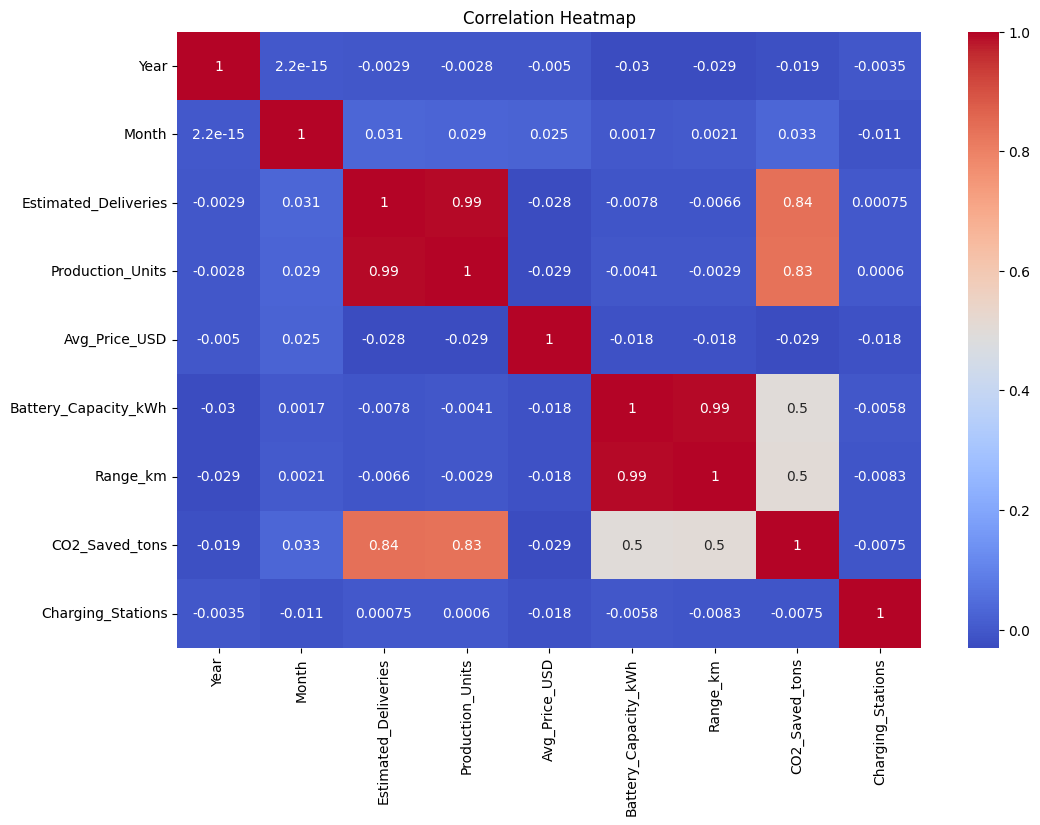

In [10]:
plt.figure(figsize=(12,8))

numeric_df = sales_df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [11]:
print(sales_df.columns)

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


In [12]:
TARGET = 'Estimated_Deliveries'

sales_df['Delivery_per_Production'] = (
    sales_df['Estimated_Deliveries'] /
    sales_df['Production_Units']
)

sales_df['Price_per_kWh'] = (
    sales_df['Avg_Price_USD'] /
    sales_df['Battery_Capacity_kWh']
)

sales_df['Range_per_kWh'] = (
    sales_df['Range_km'] /
    sales_df['Battery_Capacity_kWh']
)

sales_df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Delivery_per_Production,Price_per_kWh,Range_per_kWh
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,0.984600,773.952250,5.866667
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,0.911864,829.408667,5.840000
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,0.915334,1437.650244,5.853659
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,0.896594,744.124250,5.933333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,0.914087,957.056500,5.508333


In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_cols = sales_df.select_dtypes(include='object').columns

for col in categorical_cols:

    le = LabelEncoder()

    sales_df[col] = le.fit_transform(
        sales_df[col].astype(str)
    )

    label_encoders[col] = le

print("Categorical Columns Encoded Successfully!")


Categorical Columns Encoded Successfully!


In [14]:
X = sales_df.drop(TARGET, axis=1)

y = sales_df[TARGET]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Shape: (2640, 14)
Target Shape: (2640,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (2112, 14)
Testing Shape: (528, 14)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [17]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

print("Random Forest Model Trained Successfully!")


Random Forest Model Trained Successfully!


In [18]:
predictions = rf_model.predict(X_test_scaled)

print("Sample Predictions:")
print(predictions[:10])


Sample Predictions:
[ 7032.99  9428.12  9081.01  8993.6   8701.14 11364.38 14197.81 15172.62
  9979.66  7632.22]


In [19]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("\n========== MODEL PERFORMANCE ==========")

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


========== MODEL PERFORMANCE ==========
MAE : 69.33003787878786
MSE : 12609.418554545447
RMSE: 112.29166734244107
R2 Score: 0.9991540872924674


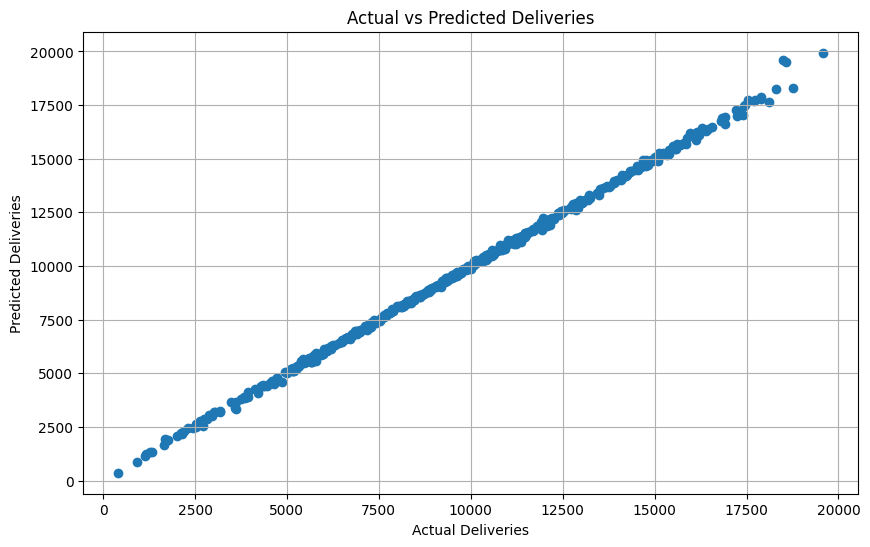

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")

plt.title("Actual vs Predicted Deliveries")

plt.grid(True)

plt.show()


In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)



Best Parameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}

Best Cross Validation Score:
0.998045683401386


In [22]:
best_model = grid_search.best_estimator_

best_predictions = best_model.predict(X_test_scaled)

best_r2 = r2_score(y_test, best_predictions)

print("\nOptimized R2 Score:", best_r2)


Optimized R2 Score: 0.9991601163202785


In [23]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                    Feature  Importance
4          Production_Units    0.990299
11  Delivery_per_Production    0.008679
13            Range_per_kWh    0.000235
8            CO2_Saved_tons    0.000206
7                  Range_km    0.000095
12            Price_per_kWh    0.000086
5             Avg_Price_USD    0.000070
10        Charging_Stations    0.000066
3                     Model    0.000062
0                      Year    0.000057


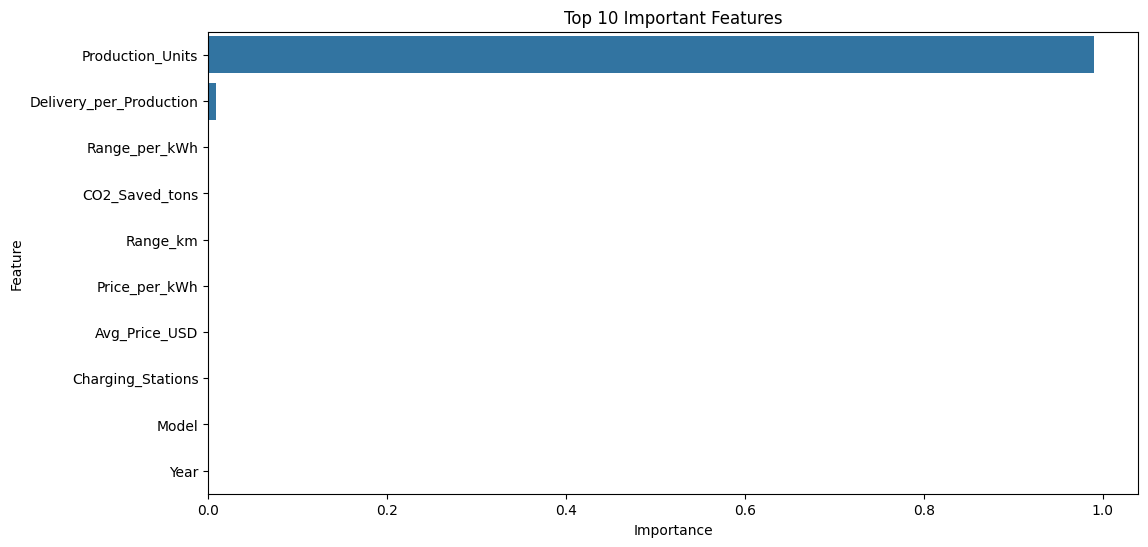

In [24]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

In [25]:
import joblib

joblib.dump(
    best_model,
    'tesla_sales_prediction_model.pkl'
)

print("Model Saved Successfully!")


Model Saved Successfully!


In [26]:
from google.colab import files

files.download('tesla_sales_prediction_model.pkl')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>